# Lab 1 — Gene-circuit dynamics in a nutshell

*The bridge from **Elowitz & Bois, "Biological Circuit Design"** ([biocircuits.github.io](https://biocircuits.github.io/))
to this course.*

If you've worked through *Biological Circuit Design* you already know the dynamics of small gene
circuits — Hill kinetics, autoregulation, the toggle switch, the repressilator, feed-forward loops,
noise. **This lab does not re-teach that material.** It re-states the *essentials you'll keep using*
— Hill functions, fixed points and linear stability, the repressilator — **in this course's
toolchain**, so you're not switching mental machinery mid-stream when Lab 5 (Hypergraph Neural ODEs)
and Lab 6 (control theory) arrive. Concretely:

| | *Biological Circuit Design* | this course |
|---|---|---|
| integrate ODEs | `scipy.integrate` | **`diffrax`** (the same integrator `hgx`'s Hypergraph Neural ODE is built on) |
| Jacobians / stability / sensitivity | by hand / `numpy` | **`jax.jacfwd` / `jax.grad`** (autodiff — through the Riccati solver, even) |
| plotting | Bokeh | `matplotlib` |
| "...and now control it" | (not covered) | **`jaxctrl`** — `is_controllable`, `lqr`, closed-loop simulation |

The **equations are identical** — a gene is still $\dot x = \beta\,\mathrm{Hill}(\cdot) - \gamma x$.
Only the software changes. For the *mechanistic derivations* (MWC, sequential binding,
ultrasensitivity), the **noise** chapters (intrinsic/extrinsic, Gillespie), and the **classic
patterning** circuits (lateral inhibition / Notch–Delta, Turing, morphogen scaling), go to
biocircuits.github.io — those are out of scope here and that book does them beautifully.

**Outline:** (1) Hill functions; (2) one gene — negative autoregulation speeds the response;
(3) two genes — the toggle switch and bistability, via `jax.jacfwd`; (4) three genes — the
repressilator, *and* the move that defines Lab 6: linearize at the unstable fixed point and do LQR
control on it; (5) exercises.

**Needs:** `jax`, `diffrax`, `jaxctrl`, `numpy`, `matplotlib` (a `uv sync` of this repo gives you
all of them).

In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import diffrax as dfx
import jaxctrl
import matplotlib.pyplot as plt

# --- the two building blocks of every gene circuit below ---
def hill_act(x, K=1.0, n=2.0):
    """Activating Hill function: 0 -> 1, half-max at x = K, steepness set by n."""
    xn = (x / K) ** n
    return xn / (1.0 + xn)

def hill_rep(x, K=1.0, n=2.0):
    """Repressing Hill function: 1 -> 0, half-max at x = K."""
    return 1.0 / (1.0 + (x / K) ** n)

# --- one small helper: integrate dy/dt = f(t, y) with diffrax (same backend hgx uses) ---
def integrate(rhs, y0, t1, n_save=200, t0=0.0, rtol=1e-6, atol=1e-9, max_steps=2**16):
    y0 = jnp.asarray(y0, dtype=float)
    sol = dfx.diffeqsolve(
        dfx.ODETerm(rhs), dfx.Tsit5(), t0=t0, t1=t1, dt0=0.01, y0=y0,
        saveat=dfx.SaveAt(ts=jnp.linspace(t0, t1, n_save)),
        stepsize_controller=dfx.PIDController(rtol=rtol, atol=atol), max_steps=max_steps,
    )
    return np.asarray(sol.ts), np.asarray(sol.ys)

def fixed_point(g, x0, iters=400):
    """Find a fixed point of x = g(x) by simple iteration (works when g is a contraction)."""
    x = jnp.asarray(x0, dtype=float)
    for _ in range(iters):
        x = 0.5 * x + 0.5 * g(x)
    return x

print("ready — diffrax", dfx.__version__, "| jaxctrl", jaxctrl.__version__)

ready — diffrax 0.7.2 | jaxctrl 0.1.0


## 1. Hill functions — the building block

A gene's production rate as a function of a regulator's concentration is, to a good first
approximation, a **Hill function**. Activation: $f(x) = \dfrac{(x/K)^n}{1 + (x/K)^n}$ — goes from
0 to 1, half-maximal at $x = K$. Repression: $f(x) = \dfrac{1}{1 + (x/K)^n}$. The **Hill
coefficient** $n$ controls steepness: $n = 1$ is a gentle hyperbola; large $n$ is a near-step
function (**ultrasensitivity** — the basis of switches). A real promoter is leaky:
$\text{rate} = \beta_0 + \beta\,\mathrm{Hill}(x)$.

*(Where does this come from? Cooperative / sequential binding of $n$ ligand molecules, or the MWC
model — the* Biological Circuit Design *chapters on "Molecular titration" and "Ultrasensitivity"
derive it. Here we just use it.)*

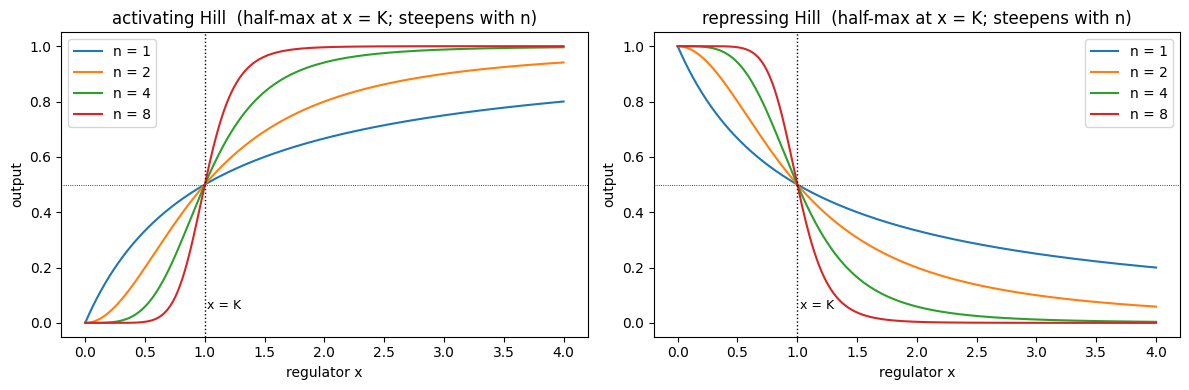

n=4 activating Hill: slope at half-max df/dx = 1.000; effective Hill coefficient (x/f)·df/dx = 2.00  (== n, as it should)


In [2]:
x = jnp.linspace(0, 4, 400)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for n in [1, 2, 4, 8]:
    ax[0].plot(x, hill_act(x, K=1.0, n=n), label=f"n = {n}")
    ax[1].plot(x, hill_rep(x, K=1.0, n=n), label=f"n = {n}")
for a, ttl in zip(ax, ["activating Hill", "repressing Hill"]):
    a.axvline(1.0, color="k", ls=":", lw=1); a.text(1.02, 0.05, "x = K", fontsize=9)
    a.axhline(0.5, color="k", ls=":", lw=0.6)
    a.set_title(ttl + "  (half-max at x = K; steepens with n)"); a.set_xlabel("regulator x"); a.set_ylabel("output"); a.legend()
plt.tight_layout(); plt.show()

# "effective Hill coefficient" = log-log slope of the activating curve at the half-max point x=K
g = jax.grad(lambda z: hill_act(z, 1.0, 4.0))(1.0)        # df/dx at x=1, n=4
eff_n = g * 1.0 / 0.5                                       # (x/f)·(df/dx) at half-max == n for a Hill fn
print(f"n=4 activating Hill: slope at half-max df/dx = {g:.3f}; effective Hill coefficient (x/f)·df/dx = {eff_n:.2f}  (== n, as it should)")

## 2. One gene: negative autoregulation speeds the response

A gene that represses *itself*: $\dot x = \dfrac{\beta}{1 + (x/K)^n} - \gamma x$. It has a single,
stable steady state $x^\*$. The classic result (Alon): **negative autoregulation reaches steady
state faster** than an unregulated gene producing the same amount — early on, when $x$ is small,
the brake is off and production runs flat-out; as $x$ rises, the brake kicks in. We check it by
integrating both (matching the unregulated gene's rate so the steady states agree), and we confirm
stability the way we will for *every* circuit from here on: compute the Jacobian by autodiff
($f'(x^\*)$ in 1-D) and check it's negative.

steady state x* = 1.516
time to reach 90% of x*:  negative autoregulation 0.81   vs   unregulated 2.32   (NAR is faster)
f'(x*) = -2.394  < 0  ->  the fixed point is stable


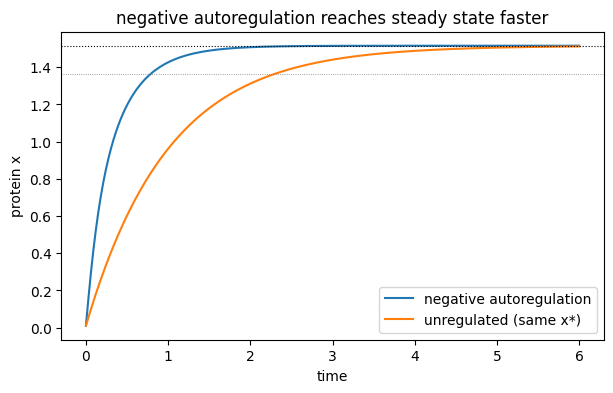

In [3]:
beta, K, n_h, gamma = 5.0, 1.0, 2.0, 1.0
def nar_rhs(t, x, args):                     # negative autoregulation
    return beta * hill_rep(x, K, n_h) - gamma * x

xss = float(fixed_point(lambda z: (beta / gamma) * hill_rep(z, K, n_h), 1.0))   # x* solves x = (β/γ)/(1+(x/K)^n)
def unreg_rhs(t, x, args):                   # unregulated gene with the SAME steady state (rate = γ·x*)
    return gamma * xss - gamma * x

t, y_nar  = integrate(nar_rhs,   0.01, t1=6.0)
_, y_unr  = integrate(unreg_rhs, 0.01, t1=6.0)
def t_to_frac(t, y, frac=0.9):
    i = int(np.argmax(np.asarray(y).ravel() >= frac * xss)); return float(np.asarray(t)[i])
print(f"steady state x* = {xss:.3f}")
print(f"time to reach 90% of x*:  negative autoregulation {t_to_frac(t, y_nar):.2f}   vs   unregulated {t_to_frac(t, y_unr):.2f}   (NAR is faster)")

# stability of the fixed point: f'(x*) by autodiff (1-D Jacobian)
fp_slope = float(jax.grad(lambda z: beta * hill_rep(z, K, n_h) - gamma * z)(xss))
print(f"f'(x*) = {fp_slope:.3f}  < 0  ->  the fixed point is stable")

plt.figure(figsize=(7, 4))
plt.plot(t, np.asarray(y_nar).ravel(), label="negative autoregulation")
plt.plot(t, np.asarray(y_unr).ravel(), label="unregulated (same x*)")
plt.axhline(xss, color="k", ls=":", lw=0.8); plt.axhline(0.9 * xss, color="grey", ls=":", lw=0.6)
plt.xlabel("time"); plt.ylabel("protein x"); plt.title("negative autoregulation reaches steady state faster"); plt.legend(); plt.show()

## 3. Two genes: the toggle switch and bistability — meet `jax.jacfwd`

Two genes that repress each other (Gardner, Cantor & Collins, *Nature* 2000):
$$\dot u = \frac{\alpha}{1 + v^n} - u, \qquad \dot v = \frac{\alpha}{1 + u^n} - v.$$
For $\alpha$ large enough and $n > 1$ this is **bistable**: two stable steady states — "$u$ high,
$v$ low" and "$v$ high, $u$ low" — separated by an unstable **saddle** point sitting on the
*separatrix* (the symmetric state $u = v$, by symmetry). Which attractor you end up in depends on
the initial condition.

We classify each fixed point exactly as we will for the Hypergraph Neural ODEs in Lab 5: linearize
there (the Jacobian $J = \partial f/\partial y$, via `jax.jacfwd`) and read off its eigenvalues —
**both real parts negative ⇒ stable node; one positive ⇒ saddle (unstable)**. (And eigenvalues
crossing the imaginary axis as a parameter varies ⇒ a Hopf bifurcation — which is exactly what
makes the repressilator in §4 oscillate.)

symmetric fixed point  u = v = 1.284
  Jacobian eigenvalues: [ 1.037+0.j -3.037+0.j]   (one > 0  ->  SADDLE / unstable)



stable fixed point (u-high): [0.062 3.999]
  Jacobian eigenvalues: [-0.955+0.j -1.045+0.j]   (both < 0  ->  STABLE node)


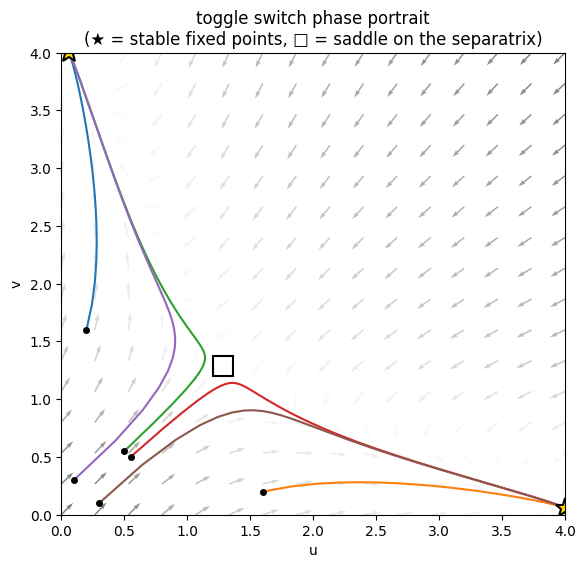

In [4]:
alpha, n_t = 4.0, 3.0
def toggle_rhs(t, y, args):
    u, v = y
    return jnp.array([alpha / (1.0 + v ** n_t) - u,
                      alpha / (1.0 + u ** n_t) - v])
jac = jax.jacfwd(lambda y: toggle_rhs(0.0, y, None))

# the symmetric (saddle) fixed point u = v = us, where us = α/(1+us^n)
us = float(fixed_point(lambda z: alpha / (1.0 + z ** n_t), 1.0))
J_sym = jac(jnp.array([us, us]))
print(f"symmetric fixed point  u = v = {us:.3f}")
print(f"  Jacobian eigenvalues: {np.asarray(jnp.linalg.eigvals(J_sym)).round(3)}   (one > 0  ->  SADDLE / unstable)")

# the two stable fixed points: integrate from biased initial conditions to find them
ics = [(0.2, 1.5), (1.5, 0.2), (0.6, 0.7), (0.7, 0.6)]
finals = []
for ic in ics:
    _, ys = integrate(toggle_rhs, ic, t1=25.0, n_save=2)
    finals.append(np.asarray(ys)[-1])
uhi = finals[0]
J_hi = jac(jnp.asarray(uhi))
print(f"\nstable fixed point (u-high): {np.round(uhi, 3)}")
print(f"  Jacobian eigenvalues: {np.asarray(jnp.linalg.eigvals(J_hi)).round(3)}   (both < 0  ->  STABLE node)")

# phase portrait: vector field + trajectories converging to the two attractors
gg = np.linspace(0.0, 4.0, 16); UU, VV = np.meshgrid(gg, gg)
DU = np.asarray(alpha / (1.0 + VV ** n_t) - UU); DV = np.asarray(alpha / (1.0 + UU ** n_t) - VV)
sp = np.hypot(DU, DV) + 1e-9
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.quiver(UU, VV, DU / sp, DV / sp, sp, cmap="Greys", alpha=0.5, scale=30, width=0.003)
for ic in [(0.2, 1.6), (1.6, 0.2), (0.5, 0.55), (0.55, 0.5), (0.1, 0.3), (0.3, 0.1)]:
    t_, ys = integrate(toggle_rhs, ic, t1=20.0)
    ax.plot(np.asarray(ys)[:, 0], np.asarray(ys)[:, 1], lw=1.5)
    ax.plot(*ic, "o", ms=4, color="k")
for fp, mk, lbl in [(uhi, "*", "stable"), (finals[1], "*", "stable"), ((us, us), "s", "saddle")]:
    ax.plot(fp[0], fp[1], mk, ms=14, mfc="none" if lbl == "saddle" else "gold", mec="k", mew=1.5)
ax.set_xlim(0, 4); ax.set_ylim(0, 4); ax.set_xlabel("u"); ax.set_ylabel("v")
ax.set_title("toggle switch phase portrait\n(★ = stable fixed points, □ = saddle on the separatrix)"); plt.show()

## 4. Three genes: the repressilator — and the move that *is* Lab 6

Close the loop with three repressors in a ring (Elowitz & Leibler, *Nature* 2000). In the
protein-only reduced form, with gene $i$ repressed by protein $i-1 \pmod 3$:
$$\dot p_i = \frac{\alpha}{1 + p_{i-1}^{\,n}} + \alpha_0 - \gamma p_i.$$
For $n$ steep enough the symmetric interior fixed point goes **unstable through a Hopf bifurcation**
(a complex-conjugate pair of Jacobian eigenvalues crosses into the right half-plane) — and the
system settles onto a **stable limit cycle**: it oscillates.

Now the new move — the one this whole course is organised around. Once you've **linearized at a
fixed point** you have a linear system $\dot{\tilde p} = A\,\tilde p$ (with $A = $ that Jacobian),
and a linear system is something **control theory** can grab. Add an actuator — a "drug" that adds
protein-1, $B = e_1$ — ask `jaxctrl` whether the pair $(A, B)$ is **controllable**, design an **LQR**
feedback $u = -K(p - p^\*)$, and apply it to the *nonlinear* ring: the oscillation is quenched. This
is exactly [`jaxctrl/examples/repressilator_control_demo.py`](https://github.com/m9h/jaxctrl/blob/main/examples/repressilator_control_demo.py),
and it is exactly the pipeline **Lab 6** runs — except there the "circuit" is a Hypergraph Neural
ODE *learned from single-cell data* and the "drug" actuates a set of transcription factors. And
because the Riccati solver behind `lqr` is differentiable, we can even take `jax.grad` of the
control cost with respect to a kinetic parameter — and the autodiff value matches a finite-difference check to four decimals, which is the credibility receipt for *differentiable control*.


interior fixed point p* = 1.727  (all 3 coords)
  Jacobian eigenvalues: [-3.367+0.j     0.183+2.049j  0.183-2.049j]   ->  2 unstable  (a Hopf pair: it oscillates)



controllable from a single protein-1 input?  True


LQR gain  K = [[ 0.555 -0.248 -0.194]]



protein-1 oscillation amplitude (late window):  open loop 3.97   ->   under LQR feedback 0.137


d(LQR cost)/d(Hill coefficient n) at n=3:  autodiff +0.0138   finite-diff +0.0138   |Δ| = 1.37e-10
  (positive ⇒ steeper repression makes the oscillator costlier to stabilise; the autodiff/FD agreement is `jax.grad`-through-the-Riccati-solver working as advertised)


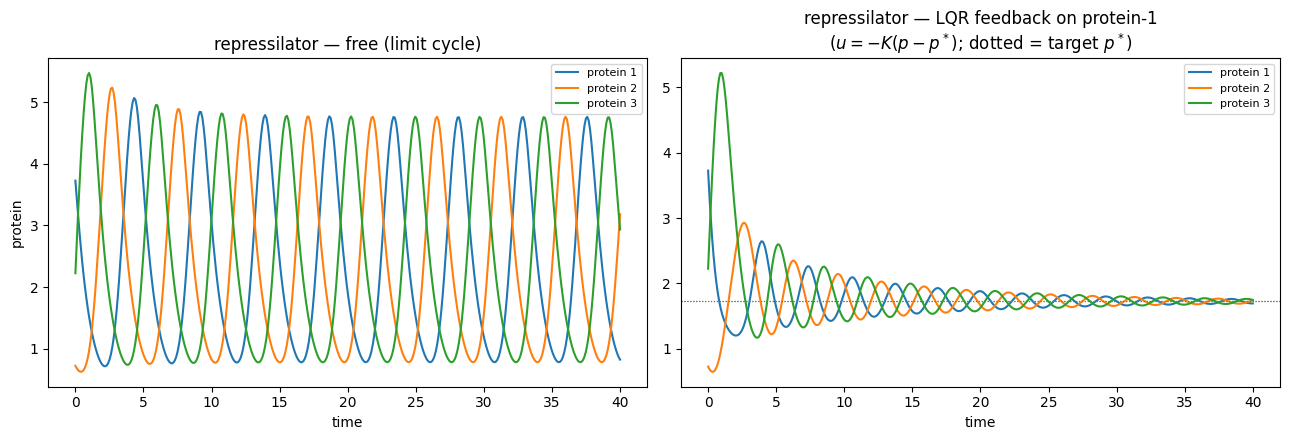

In [5]:
ALPHA, ALPHA0, NH, GAM = 10.0, 0.1, 3.0, 1.0
PERM = jnp.array([2, 0, 1])                        # gene i is repressed by protein PERM[i] (= i-1 mod 3)
def repress_rhs(t, p, args):
    return ALPHA / (1.0 + p[PERM] ** NH) + ALPHA0 - GAM * p

# interior symmetric fixed point p* (all coords equal)
ps    = float(fixed_point(lambda z: ALPHA / (1.0 + z ** NH) + ALPHA0, 1.0))
pstar = jnp.full(3, ps)
A     = jax.jacfwd(lambda p: repress_rhs(0.0, p, None))(pstar)
eig   = jnp.linalg.eigvals(A)
print(f"interior fixed point p* = {ps:.3f}  (all 3 coords)")
print(f"  Jacobian eigenvalues: {np.asarray(eig).round(3)}   ->  {int((eig.real > 1e-9).sum())} unstable  (a Hopf pair: it oscillates)")

# the free (oscillating) trajectory from a perturbed start
p0 = pstar + jnp.array([2.0, -1.0, 0.5])
t, p_free = integrate(repress_rhs, p0, t1=40.0, n_save=400)

# --- linearize -> control: jaxctrl ---
B = jnp.zeros((3, 1)).at[0, 0].set(1.0)            # "drug" adding protein-1
print(f"\ncontrollable from a single protein-1 input?  {bool(jaxctrl.is_controllable(A, B))}")
em  = float(jnp.max(eig.real)); A_h = A - max(em + 0.5, 0.0) * jnp.eye(3)   # Hurwitz copy for the ∞-horizon LQR
K, X = jaxctrl.lqr(A_h, B, jnp.eye(3), jnp.eye(1))
print(f"LQR gain  K = {np.asarray(K).round(3)}")

def closed_loop_rhs(t, p, args):                   # u = -K (p - p*), saturated
    u = jnp.clip(-(K @ (p - pstar)), -8.0, 8.0)
    return repress_rhs(t, p, None) + B[:, 0] * u[0]
_, p_ctrl = integrate(closed_loop_rhs, p0, t1=40.0, n_save=400)
amp = lambda Y, j=0: float(np.ptp(np.asarray(Y)[-120:, j]))
print(f"\nprotein-1 oscillation amplitude (late window):  open loop {amp(p_free):.2f}   ->   under LQR feedback {amp(p_ctrl):.3f}")

# differentiable design: how the control cost responds to the Hill coefficient
def lqr_cost(n):
    def rhs(p): return ALPHA / (1.0 + p[PERM] ** n) + ALPHA0 - GAM * p
    psn = jnp.asarray(1.0)
    for _ in range(300): psn = 0.5 * psn + 0.5 * (ALPHA / (1.0 + psn ** n) + ALPHA0)
    An  = jax.jacfwd(rhs)(jnp.full(3, psn))
    emn = jnp.maximum(jnp.max(jnp.linalg.eigvals(An).real) + 0.5, 0.0)
    _, Xn = jaxctrl.lqr(An - emn * jnp.eye(3), B, jnp.eye(3), jnp.eye(1))
    y0 = p0 - jnp.full(3, psn)
    return y0 @ Xn @ y0
g_ad = float(jax.grad(lqr_cost)(3.0))
eps = 1e-3
g_fd = (float(lqr_cost(3.0 + eps)) - float(lqr_cost(3.0 - eps))) / (2.0 * eps)
print(f"d(LQR cost)/d(Hill coefficient n) at n=3:  autodiff {g_ad:+.4f}   finite-diff {g_fd:+.4f}   |Δ| = {abs(g_ad - g_fd):.2e}")
print("  (positive ⇒ steeper repression makes the oscillator costlier to stabilise; the autodiff/FD agreement is `jax.grad`-through-the-Riccati-solver working as advertised)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
cyc = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for j in range(3):
    ax[0].plot(t, np.asarray(p_free)[:, j], color=cyc[j], label=f"protein {j+1}")
ax[0].set_title("repressilator — free (limit cycle)"); ax[0].set_xlabel("time"); ax[0].set_ylabel("protein"); ax[0].legend(fontsize=8)
for j in range(3):
    ax[1].plot(t, np.asarray(p_ctrl)[:, j], color=cyc[j], label=f"protein {j+1}")
    ax[1].axhline(float(pstar[j]), color=cyc[j], ls=":", lw=0.8)
ax[1].set_title("repressilator — LQR feedback on protein-1\n($u=-K(p-p^*)$; dotted = target $p^*$)"); ax[1].set_xlabel("time"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. Exercises

**(a) Positive autoregulation → bistability.** A gene that activates itself:
$\dot x = \beta_0 + \beta\,\mathrm{hill\_act}(x, K, n) - \gamma x$. For $n \ge 2$ and the right
$\beta/\gamma$ this has *two* stable fixed points (off-ish and on-ish) plus an unstable one between
them. Find, by sweeping $\beta$ (or $\beta_0$), where the second stable state appears (the **saddle-
node bifurcation**); plot $x^\*$ vs $\beta$ (a fold). A starter is below. *(biocircuits: the
"Bistability" chapter.)*

**(b) From the toggle to the repressilator.** Take the 2-gene mutual-repression toggle from §3 and
add a third repressor to close a 3-ring. Sweep the Hill coefficient $n$; with `jax.jacfwd` at the
symmetric fixed point, find the $n$ at which the eigenvalues cross the imaginary axis (the Hopf) and
the ring starts to oscillate. (You'll re-derive the §4 result from the §3 machinery.)

**(c) The coherent feed-forward loop — a persistence detector.** X activates Y; X *and* Y together
(AND logic) activate Z: $\dot y = \mathrm{hill\_act}(x) - y$, $\dot z = \mathrm{hill\_act}(x)\cdot
\mathrm{hill\_act}(y) - z$. Drive $x(t)$ with a *short* pulse and then a *long* pulse; show $z$ only
fires for the long one — the FFL filters transient inputs. *(Alon, "Network motifs";
biocircuits: the "Feed-forward loops" chapter.)*

**(d) Noise.** Everything above is deterministic. Real gene expression is stochastic — *Biological
Circuit Design* covers this with the **Gillespie algorithm** (intrinsic vs extrinsic noise, the
Fano factor, the role of bursting). Either go read those chapters, or — for credit — implement a
tiny stochastic-simulation version of the negative-autoregulated gene from §2 in JAX
(`jax.random` + a discrete birth–death process) and compare its variance to the deterministic
steady state.

A starter for (a):

β      #fixed points   (bistable region = 3)
 0.50      1            [0.201]
 1.06      1            [0.202]
 1.62      3            [0.203 0.985 1.608]
 2.18      3            [0.204 0.773 2.303]
 2.74      3            [0.205 0.678 2.899]
 3.30      3            [0.206 0.617 3.474]


 3.86      3            [0.207 0.571 4.042]
 4.42      3            [0.208 0.536 4.605]
 4.97      3            [0.21  0.506 5.168]
 5.53      3            [0.211 0.481 5.729]

bistable for roughly β ∈ [1.62, 5.53]  — that's the fold/cusp region.


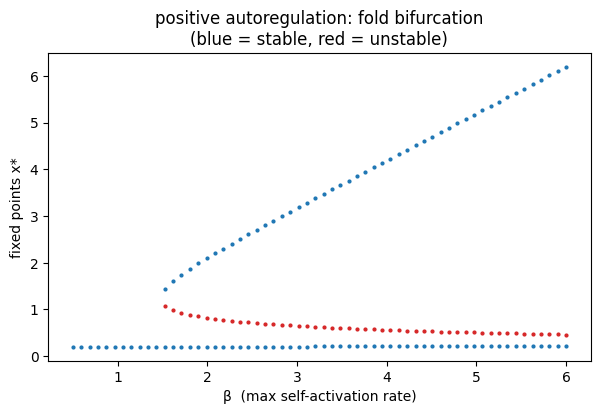

In [6]:
# --- Exercise (a) starter: positive autoregulation, look for bistability ---
beta0_pa, K_pa, n_pa, gamma_pa = 0.2, 1.0, 4.0, 1.0

def pos_autoreg_rhs(t, x, args, beta):
    return beta0_pa + beta * hill_act(x, K_pa, n_pa) - gamma_pa * x

def steady_states(beta):
    """Return all real fixed points of 0 = β0 + β·hill_act(x) - γx on a coarse scan, refined by integration."""
    grid = np.linspace(0.0, beta / gamma_pa + beta0_pa + 1.0, 400)
    f = beta0_pa + beta * np.asarray(hill_act(jnp.asarray(grid), K_pa, n_pa)) - gamma_pa * grid
    # sign changes of f bracket fixed points
    roots = []
    for i in range(len(grid) - 1):
        if f[i] == 0 or f[i] * f[i + 1] < 0:
            # refine by a few bisection steps
            lo, hi = grid[i], grid[i + 1]
            for _ in range(40):
                mid = 0.5 * (lo + hi)
                fm = beta0_pa + beta * float(hill_act(jnp.asarray(mid), K_pa, n_pa)) - gamma_pa * mid
                if (beta0_pa + beta * float(hill_act(jnp.asarray(lo), K_pa, n_pa)) - gamma_pa * lo) * fm <= 0:
                    hi = mid
                else:
                    lo = mid
            roots.append(0.5 * (lo + hi))
    return roots

betas = np.linspace(0.5, 6.0, 60)
print("β      #fixed points   (bistable region = 3)")
bistable = []
for b in betas[::6]:
    fps = steady_states(b)
    print(f"{b:5.2f}      {len(fps)}            {np.round(fps, 3)}")
    if len(fps) == 3: bistable.append(b)
if bistable:
    print(f"\nbistable for roughly β ∈ [{min(bistable):.2f}, {max(bistable):.2f}]  — that's the fold/cusp region.")

# now: (i) plot x* vs β (the fold diagram), marking which branches are stable (f'(x*) < 0);
#      (ii) integrate pos_autoreg_rhs from a low and a high IC inside the bistable window to
#           confirm two attractors;  (iii) then do (b), (c), (d).
plt.figure(figsize=(7, 4))
for b in betas:
    for x_star in steady_states(b):
        slope = float(jax.grad(lambda z: pos_autoreg_rhs(0.0, z, None, b))(x_star))
        plt.plot(b, x_star, ".", color=("tab:blue" if slope < 0 else "tab:red"), ms=4)
plt.xlabel("β  (max self-activation rate)"); plt.ylabel("fixed points x*")
plt.title("positive autoregulation: fold bifurcation\n(blue = stable, red = unstable)"); plt.show()

## Recap & next

You now have the dynamical-systems toolkit **in this course's idiom**:

- **`diffrax`** for integrating ODEs — the very same integrator inside `hgx`'s Hypergraph Neural
  ODE (Lab 5) and `jaxctrl`'s closed-loop simulations (Lab 6);
- **`jax.jacfwd`** for the Jacobian at a fixed point ⇒ linear stability (stable node / saddle /
  Hopf) — the move you'll make on a *learned* genome-scale model in Lab 5;
- **`jax.grad`** for sensitivities — including straight through the Riccati equation;
- **`jaxctrl`** — `is_controllable`, `lqr`, closed-loop simulation: the "linearize a circuit, then
  control it" pipeline that Lab 6 scales up to a learned regulome ODE and the "anatomical compiler."

**Lab 2 — Regulomes and hypergraphs** leaves single circuits behind: the regulome as a *hypergraph*
(720 TFs, 2,792 genes), inferred from single-cell multiomics, and why a regulon is a *hyperedge*,
not a clique.

*Go to [biocircuits.github.io](https://biocircuits.github.io/)* for the mechanistic derivations
(Hill / MWC / ultrasensitivity), the **noise** chapters, the **feed-forward-loop** functions, and
the classic **patterning** circuits — those are the foundations this course assumes and does not
reproduce.

*References:* Elowitz & Bois, *Biological Circuit Design* (Caltech, biocircuits.github.io); Alon,
*An Introduction to Systems Biology* (2nd ed.); Gardner TS, Cantor CR, Collins JJ. "Construction of
a genetic toggle switch in *Escherichia coli*." *Nature* 403:339–342 (2000); Elowitz MB, Leibler S.
"A synthetic oscillatory network of transcriptional regulators." *Nature* 403:335–338 (2000).